In [1]:
import fastf1
import pandas as pd
import numpy as np
import sklearn
import os
import time

print("fastf1 version:", fastf1.__version__)
print("fastf1 version:", pd.__version__)
print("sklearn version:", sklearn.__version__)


fastf1 version: 3.8.0
fastf1 version: 2.3.3
sklearn version: 1.8.0


In [2]:
session = fastf1.get_session(2026,"Australian Grand Prix","r")
session.load(telemetry= False, weather = False, messages = False)

results = session.results

results = results.drop(columns=["BroadcastName", "Abbreviation", "TeamColor", "HeadshotUrl", "CountryCode", "ClassifiedPosition"])
print(results.columns)
print(results.head(5))
results.to_csv('AustralianGpP.csv', index = False)

req         WARNING 	DEFAULT CACHE ENABLED! (929.32 MB) C:\Users\Ramir\AppData\Local\Temp\fastf1
core           INFO 	Loading data for Australian Grand Prix - Race [v3.8.0]
req            INFO 	Using cached data for session_info
req            INFO 	Using cached data for driver_info
req            INFO 	Using cached data for session_status_data
req            INFO 	Using cached data for lap_count
req            INFO 	Using cached data for track_status_data
req            INFO 	Using cached data for _extended_timing_data
req            INFO 	Using cached data for timing_app_data
core           INFO 	Processing timing data...
core        WARNING 	No lap data for driver 81
core        WARNING 	Failed to perform lap accuracy check - all laps marked as inaccurate (driver 81)
core           INFO 	Finished loading data for 22 drivers: ['63', '12', '16', '44', '1', '3', '87', '41', '5', '10', '31', '23', '30', '43', '55', '11', '18', '14', '77', '6', '81', '27']


Index(['DriverNumber', 'DriverId', 'TeamName', 'TeamId', 'FirstName',
       'LastName', 'FullName', 'Position', 'GridPosition', 'Q1', 'Q2', 'Q3',
       'Time', 'Status', 'Points', 'Laps'],
      dtype='object')
   DriverNumber   DriverId  TeamName    TeamId FirstName   LastName  \
63           63    russell  Mercedes  mercedes    George    Russell   
12           12  antonelli  Mercedes  mercedes      Kimi  Antonelli   
16           16    leclerc   Ferrari   ferrari   Charles    Leclerc   
44           44   hamilton   Ferrari   ferrari     Lewis   Hamilton   
1             1     norris   McLaren   mclaren     Lando     Norris   

           FullName  Position  GridPosition  Q1  Q2  Q3  \
63   George Russell       1.0           1.0 NaT NaT NaT   
12   Kimi Antonelli       2.0           2.0 NaT NaT NaT   
16  Charles Leclerc       3.0           4.0 NaT NaT NaT   
44   Lewis Hamilton       4.0           7.0 NaT NaT NaT   
1      Lando Norris       5.0           6.0 NaT NaT NaT   

     

In [6]:

def time_to_seconds(t):
    try:
        return round(pd.to_timedelta(str(t)).total_seconds(), 3)
    except:
        return None

def load_race_weekend(year, round_num):
    try:
        # Qualifying
        quali = fastf1.get_session(year, round_num, 'Q')
        quali.load(telemetry=False, weather=False, messages=False)
        
        quali_df = quali.results[[
            'DriverNumber', 'FullName', 'TeamName',
            'Position', 'Q1', 'Q2', 'Q3'
        ]].copy()
        quali_df = quali_df.rename(columns={'Position': 'GridPosition'})
        quali_df['Q1_seconds'] = quali_df['Q1'].apply(time_to_seconds)
        quali_df['Q2_seconds'] = quali_df['Q2'].apply(time_to_seconds)
        quali_df['Q3_seconds'] = quali_df['Q3'].apply(time_to_seconds)
        quali_df = quali_df.drop(columns=['Q1', 'Q2', 'Q3'])

        # Race
        race = fastf1.get_session(year, round_num, 'R')
        race.load(telemetry=False, weather=False, messages=False)
        
        race_df = race.results[['FullName', 'Position', 'Status', 'Points', 'Time']].copy()
        race_df['TimeDelta'] = race_df['Time'].apply(time_to_seconds)
        race_df = race_df.rename(columns={'Position': 'RacePosition'})
        race_df = race_df.drop(columns='Time')

        # Merge
        merged = pd.merge(quali_df, race_df, on='FullName', how='inner')
        merged['Season'] = year
        merged['Round'] = round_num
        merged['EventName'] = race.event['EventName']
        merged['FinishPosition'] = pd.to_numeric(merged['RacePosition'], errors='coerce')

        return merged

    except Exception as e:
        print(f"  ✗ Round {round_num} skipped: {e}")
        return None


# ── Run with resume support ────────────────────────────────────────────────────
all_seasons = []

for year in range(2025, 2026):
    print(f"\n{'='*40}")
    print(f"  Loading {year}...")
    print(f"{'='*40}")

    season_file = f'data/f1_{year}.csv'
    schedule = fastf1.get_event_schedule(year, include_testing=False)
    all_rounds = list(schedule['RoundNumber'])

    # ── Resume logic ──────────────────────────────────────────────────────────
    existing_df = None
    completed_rounds = set()

    if os.path.exists(season_file):
        existing_df = pd.read_csv(season_file)
        completed_rounds = set(existing_df['Round'].unique())
        print(f"  ✓ Found existing data — {len(completed_rounds)} rounds already loaded: {sorted(completed_rounds)}")
    
    remaining_rounds = [r for r in all_rounds if r not in completed_rounds]

    if not remaining_rounds:
        print(f"  ✓ All rounds complete — loading from CSV")
        all_seasons.append(existing_df)
        continue

    print(f"  → Rounds to fetch: {remaining_rounds}")

    # ── Fetch missing rounds ───────────────────────────────────────────────────
    season_data = []
    for round_num in remaining_rounds:
        print(f"Loading round {round_num}...", end=' ')
        df = load_race_weekend(year, round_num)
        if df is not None:
            season_data.append(df)
            print(f"✓ {df['EventName'].iloc[0]}")
        time.sleep(3)

    # ── Merge new data with existing and save ─────────────────────────────────
    frames = []
    if existing_df is not None:
        frames.append(existing_df)
    if season_data:
        frames.append(pd.concat(season_data, ignore_index=True))

    if frames:
        year_df = pd.concat(frames, ignore_index=True)
        year_df = year_df.sort_values('Round').reset_index(drop=True)  # keep rounds in order
        year_df.to_csv(season_file, index=False)
        print(f"  ✓ Saved {len(year_df['Round'].unique())} total rounds for {year}")
        all_seasons.append(year_df)

    print(f"\nDone!")

core           INFO 	Loading data for Monaco Grand Prix - Qualifying [v3.8.0]
req            INFO 	Using cached data for session_info
req            INFO 	Using cached data for driver_info



  Loading 2025...
  ✓ Found existing data — 7 rounds already loaded: [np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6), np.int64(7)]
  → Rounds to fetch: [8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24]
Loading round 8... 

req            INFO 	Using cached data for session_status_data
req            INFO 	Using cached data for track_status_data
req            INFO 	Using cached data for _extended_timing_data
req            INFO 	Using cached data for timing_app_data
core           INFO 	Processing timing data...
core           INFO 	Finished loading data for 20 drivers: ['4', '16', '81', '44', '1', '6', '14', '31', '30', '23', '55', '22', '27', '63', '12', '5', '87', '10', '18', '43']
core           INFO 	Loading data for Monaco Grand Prix - Race [v3.8.0]
req            INFO 	Using cached data for session_info
req            INFO 	Using cached data for driver_info
req            INFO 	No cached data found for session_status_data. Loading data...
_api           INFO 	Fetching session status data...
req            INFO 	Data has been written to cache!
req            INFO 	No cached data found for lap_count. Loading data...
_api           INFO 	Fetching lap count data...
req            INFO 	Data has been w

✓ Monaco Grand Prix


core           INFO 	Loading data for Spanish Grand Prix - Qualifying [v3.8.0]
req            INFO 	No cached data found for session_info. Loading data...
_api           INFO 	Fetching session info data...


...

Loading round 22...   ✗ Round 22 skipped: any API: 500 calls/h


core           INFO 	Loading data for Qatar Grand Prix - Qualifying [v3.8.0]
req            INFO 	No cached data found for session_info. Loading data...
_api           INFO 	Fetching session info data...


Loading round 23...   ✗ Round 23 skipped: any API: 500 calls/h


core           INFO 	Loading data for Abu Dhabi Grand Prix - Qualifying [v3.8.0]
req            INFO 	No cached data found for session_info. Loading data...
_api           INFO 	Fetching session info data...


Loading round 24...   ✗ Round 24 skipped: any API: 500 calls/h
  ✓ Saved 21 total rounds for 2025

Done!


In [ ]:

# Load and combine all seasons
years = range(2020, 2025)  # 2020-2024
dfs = [pd.read_csv(f'data/f1_{year}.csv') for year in years]

combined = pd.concat(dfs, ignore_index=True)
combined = combined.sort_values(['Season', 'Round']).reset_index(drop=True)


combined.to_csv('data/f1_2020_2024.csv', index=False)
print(f"Combined dataset: {len(combined)} rows across {combined['Season'].nunique()} seasons")

Combined dataset: 2139 rows across 5 seasons


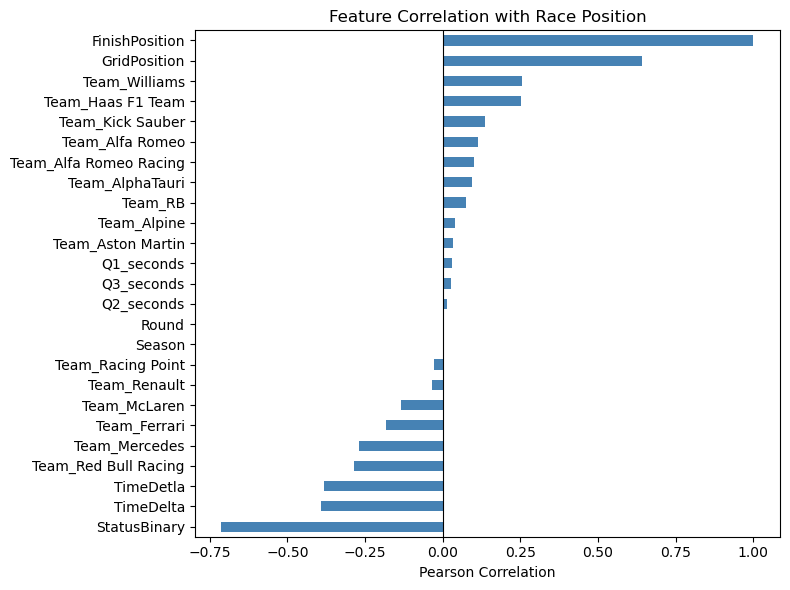

In [11]:
import seaborn as sns
import matplotlib.pyplot as plt


df = pd.read_csv('data/f1_2020_2024.csv')

df["StatusBinary"] = df["Status"].eq("Finished").astype(int)

df_fin = df[df["Status"] == "Finished"].copy()

df = df.drop(columns = ['Time', 'Podium', 'Points', 'Status', 'DriverNumber'])



team_dummies = pd.get_dummies(df["TeamName"], prefix="Team")

df_numeric = pd.concat([df.drop(columns=['TeamName', 'FullName', 'EventName']), team_dummies], axis = 1)

df_numeric.head()

corr_matrix = df_numeric.corr()['RacePosition'].drop('RacePosition').sort_values()

corr_matrix.plot(kind='barh', figsize=(8, 6), color='steelblue')
plt.axvline(0, color='black', linewidth=0.8)
plt.title('Feature Correlation with Race Position')
plt.xlabel('Pearson Correlation')
plt.tight_layout()
plt.show()


Text(0.5, 1.0, 'Race Finish vs Grid Position')

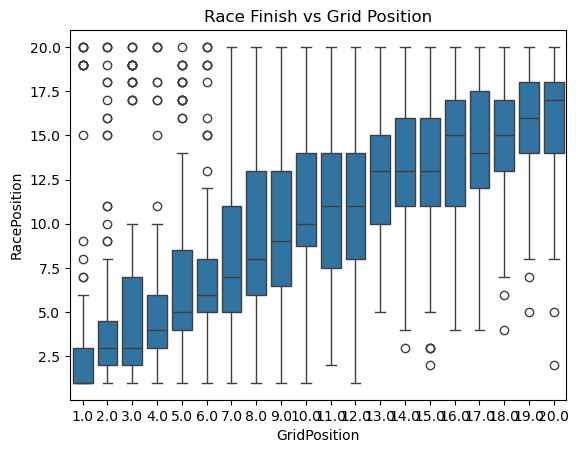

In [12]:
sns.boxplot(data = df, x = 'GridPosition', y ='RacePosition')
plt.title('Race Finish vs Grid Position')

In [20]:

for year in range(2020, 2025):
    newDF = pd.read_csv(f'data/f1_{year}.csv') 
    drivers = newDF.groupby('TeamName')['RacePosition'].agg(['mean', 'std']).sort_values('mean')
    print(f"\n DRIVER STATS FOR {year}")
    print(f"{'=' * 40}")
    print(drivers)


 DRIVER STATS FOR 2020
                        mean       std
TeamName                              
Mercedes            3.735294  4.223375
Red Bull Racing     7.705882  6.206201
McLaren             8.617647  4.817988
Renault             8.941176  4.741443
Racing Point        9.205882  5.902128
Ferrari            10.705882  5.390954
AlphaTauri         10.705882  4.713163
Alfa Romeo Racing  13.852941  2.786682
Williams           15.735294  2.632073
Haas F1 Team       15.794118  2.804535

 DRIVER STATS FOR 2021
                        mean       std
TeamName                              
Mercedes            5.409091  5.743827
Red Bull Racing     5.840909  6.069149
Ferrari             7.113636  3.948599
McLaren             7.795455  3.915263
Alpine             10.250000  4.636182
AlphaTauri         11.272727  5.271087
Aston Martin       12.000000  4.404015
Alfa Romeo Racing  13.204545  2.698661
Williams           14.727273  3.787149
Haas F1 Team       17.325581  1.972682

 DRIVER STATS F

In [23]:
#Based on the above data, it's clear that there is a decline in race finish position from
#Lewis hamilton, while there is an increase in performance from Lando for example
#Because of this, it would be good to encode some sort of weighting system for recent performance more than older performances
#for both the drivers and teams

df = pd.read_csv('data/f1_2020_2024.csv')

df = df.sort_values(['Season', 'Round']).reset_index(drop=True)

df['driver_rolling_avg_3'] = (
    df.groupby('FullName')['RacePosition']
    .transform(lambda x: x.shift(1).rolling(window=3, min_periods=1).mean())
)

df['driver_rolling_avg_5'] = (
    df.groupby('FullName')['RacePosition']
    .transform(lambda x: x.shift(1).rolling(window=5, min_periods=1).mean())
)

# Rolling std deviation (consistency metric)
df['driver_rolling_std_5'] = (
    df.groupby('FullName')['RacePosition']
    .transform(lambda x: x.shift(1).rolling(window=5, min_periods=1).std())
)

# Last race finish (most recent form signal)
df['driver_last_finish'] = (
    df.groupby('FullName')['RacePosition']
    .transform(lambda x: x.shift(1))
)

print(f"{'=' * 40}")
print("\n Successfully Added Rolling Averages for the past 3 and 5 races for all drivers")


 Successfully Added Rolling Averages for the past 3 and 5 races for all drivers


In [25]:
#Adding rolling averages for teams and their positions
df['team_rolling_avg_5'] = (
    df.groupby('TeamName')['RacePosition']
    .transform(lambda x: x.shift(1).rolling(window=5, min_periods=1).mean())
)

df['team_rolling_avg_3'] = (
    df.groupby('TeamName')['RacePosition']
    .transform(lambda x: x.shift(1).rolling(window=3, min_periods=1).mean())
)

print(f"{'=' * 40}")
print("\n Successfully Added Rolling Averages for the past 3 and 5 races for all teams")


 Successfully Added Rolling Averages for the past 3 and 5 races for all teams


In [28]:
lewis = df[df['FullName'] == 'Lewis Hamilton'][
    ['Season', 'Round', 'RacePosition', 'driver_last_finish', 'driver_rolling_avg_3']
].head(10)
print(lewis)

print(f"\n {"=" * 40}")

mercedes = df[df['TeamName'] == 'Mercedes'][
    ['Season', 'Round', 'RacePosition', 'team_rolling_avg_3', 'team_rolling_avg_5']
].head(10)
print(mercedes)

     Season  Round  RacePosition  driver_last_finish  driver_rolling_avg_3
1      2020      1           4.0                 NaN                   NaN
20     2020      2           1.0                 4.0              4.000000
40     2020      3           1.0                 1.0              2.500000
60     2020      4           1.0                 1.0              2.000000
81     2020      5           2.0                 1.0              1.000000
100    2020      6           1.0                 2.0              1.333333
120    2020      7           1.0                 1.0              1.333333
140    2020      8           7.0                 1.0              1.333333
160    2020      9           1.0                 7.0              3.000000
180    2020     10           3.0                 1.0              3.000000

    Season  Round  RacePosition  team_rolling_avg_3  team_rolling_avg_5
0     2020      1           1.0                 NaN                 NaN
1     2020      1           4.

In [29]:
# Step 1: Get each driver's qualifying time (use best available Q time)
df['best_q_time'] = df['Q3_seconds'].fillna(df['Q2_seconds']).fillna(df['Q1_seconds'])

# Step 2: Calculate teammate's best Q time for the same race
teammate_avg = (
    df.groupby(['Season', 'Round', 'TeamName'])['best_q_time']
    .transform('mean')
)

# Step 3: Delta = driver's time minus team average
# Positive = slower than teammate, Negative = faster than teammate
df['quali_delta_to_teammate'] = df['best_q_time'] - teammate_avg

In [ ]:
# Pick a race and check Hamilton vs Bottas
check = df[
    (df['Season'] == 2020) & 
    (df['Round'] == 1) & 
    (df['TeamName'] == 'Mercedes')
][['FullName', 'best_q_time', 'quali_delta_to_teammate']]
print(check)


          FullName  best_q_time  quali_delta_to_teammate
0  Valtteri Bottas       62.939                   -0.006
1   Lewis Hamilton       62.951                    0.006


In [ ]:
df.columns
df.drop(column = 'DriverNumber')

leakage = [f'FinishPosition', 'Points', 'TimeDelta', 'TimeDetla', 'Podium', 'Status', 'Time']

teamDummy = pd.get_dummies(df['TeamName'], prefix = 'Team')
driverDummy = pd.get_dummies(df['FullName'], prefix = 'Driver')


Index(['DriverNumber', 'FullName', 'TeamName', 'GridPosition', 'Q1_seconds',
       'Q2_seconds', 'Q3_seconds', 'RacePosition', 'Status', 'Points',
       'TimeDelta', 'Season', 'Round', 'EventName', 'FinishPosition', 'Time',
       'TimeDetla', 'Podium', 'driver_rolling_avg_3', 'driver_rolling_avg_5',
       'driver_rolling_std_5', 'driver_last_finish', 'team_rolling_avg_5',
       'team_rolling_avg_3', 'best_q_time', 'quali_delta_to_teammate'],
      dtype='object')